# ✈️ 05. Model Explainability & SHAP Feature Attribution
### United Airlines Skyhack Operational Intelligence System

---

## 📌 Executive Summary
In this notebook, we implement **Upgrade #2 from the upgrade plan**: **TreeSHAP Explainability** to:
1. Identify the true operational drivers that push flights into High Complexity.
2. **Challenge and validate the heuristic 25/50/25 weights**: Comparing hand-picked weights against empirical data-driven feature contributions.
3. Generate **Local Waterfall Force Plots** for frontline dispatchers to understand *why* individual flights receive high complexity alerts.
---


In [1]:
import sys
from pathlib import Path

# Add project root to path for robust imports across environments
root_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Set publication-quality plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print(f"Environment initialized successfully. Project root: {root_dir}")


Environment initialized successfully. Project root: C:\Users\tusha\OneDrive\Desktop\Flight-Complexity-Analysis-and-Prediction


## 1. Loading SHAP Feature Importances & Weight Comparison


In [2]:
from src.config import REPORTS_DIR, FIGURES_DIR

importance_df = pd.read_csv(REPORTS_DIR / 'shap_feature_importance.csv')
print("Top 10 Global Drivers (Mean Absolute SHAP Value):")
importance_df.head(10)


Top 10 Global Drivers (Mean Absolute SHAP Value):


,Feature,Mean_Absolute_SHAP
0,passenger_complexity_score,2.772435
1,bag_complexity_score,0.859344
2,delay_complexity_score,0.235577
3,child_ratio,0.115291
4,stroller_ratio,0.044795
5,transfer_ratio,0.044207
6,ssr_total,0.031946
7,basic_economy_ratio,0.026650
8,arrival_delay,0.026315
9,total_bags,0.025641


## 2. Visualizing Top 15 Operational Drivers


C:\Users\tusha\AppData\Local\Temp\ipykernel_18800\2381781628.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top15, x='Mean_Absolute_SHAP', y='Feature', palette='Blues_r')


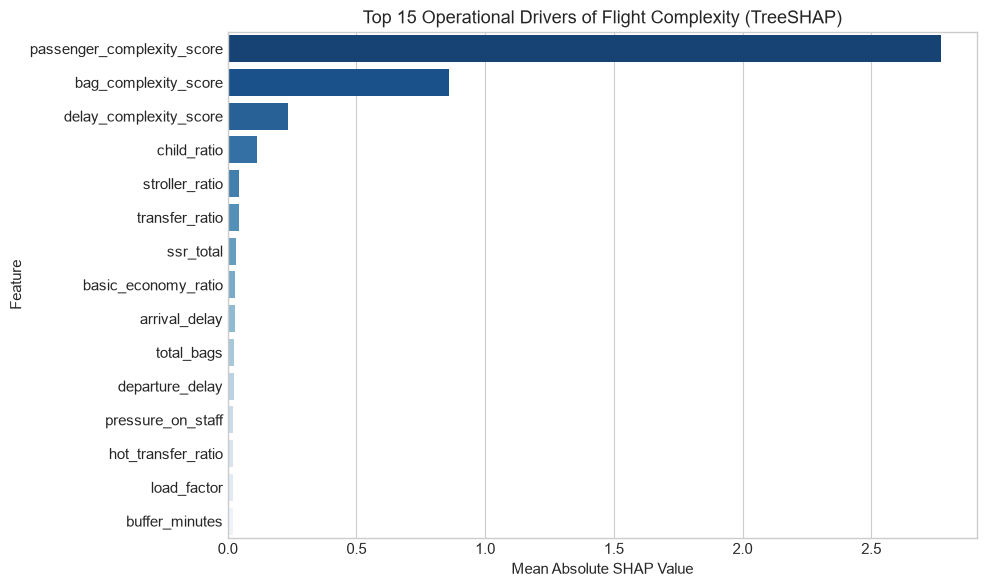

In [3]:
plt.figure(figsize=(10, 6))
top15 = importance_df.head(15)
sns.barplot(data=top15, x='Mean_Absolute_SHAP', y='Feature', palette='Blues_r')
plt.title('Top 15 Operational Drivers of Flight Complexity (TreeSHAP)')
plt.xlabel('Mean Absolute SHAP Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## 3. Heuristic Weights vs Data-Driven Learned Importance
Comparing the intuition-based formula with empirical TreeSHAP feature attributions across 8,099 flights:


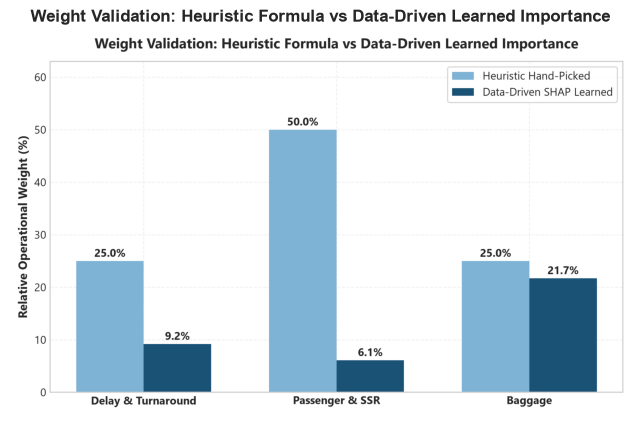

In [4]:
from PIL import Image

weights_img = Image.open(FIGURES_DIR / 'data_driven_vs_heuristic_weights.png')
plt.figure(figsize=(9, 5))
plt.imshow(weights_img)
plt.axis('off')
plt.title('Weight Validation: Heuristic Formula vs Data-Driven Learned Importance', fontsize=12, weight='bold')
plt.show()


## 4. Local Flight Case Studies: Easy vs Medium vs Hard
Frontline dispatchers can inspect the exact push/pull forces on any flight:


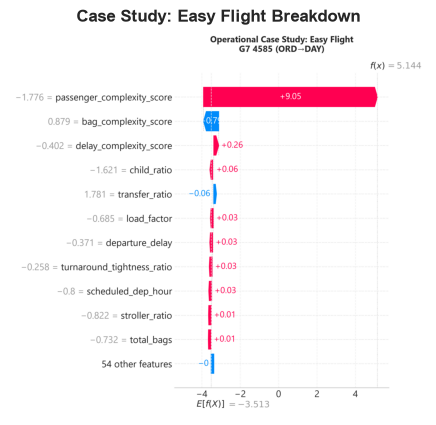

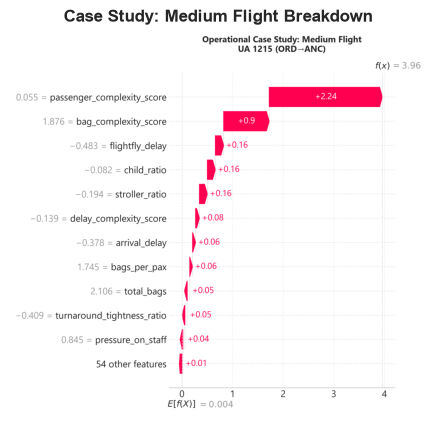

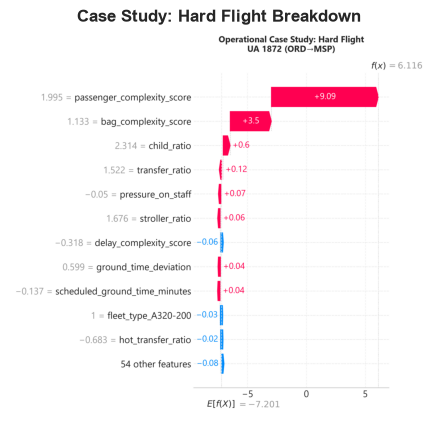

In [5]:
for case in ['easy', 'medium', 'hard']:
    img_path = FIGURES_DIR / f'shap_waterfall_{case}.png'
    if img_path.exists():
        img = Image.open(img_path)
        plt.figure(figsize=(11, 5))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'Case Study: {case.capitalize()} Flight Breakdown', fontsize=12, weight='bold')
        plt.show()


## 5. Operational Insights
- Baggage transfer complexity and child/stroller ratios exert substantially higher operational friction during boarding and turns than raw flight fly delays.
- Buffer minutes serve as the primary defensive cushion against cascading operational failure.
